# Exploratory Data Analysis (EDA) - Fund Prediction Inputs

Notebook ini menganalisis data dummy yang digunakan untuk estimasi kebutuhan dana. Volume berasal dari data historis, sedangkan harga acuan ditentukan oleh stakeholder. Estimasi dana dihitung menggunakan rumus:

$$\text{Estimated Fund} = \text{Accepted Volume} \times \text{Reference Price}$$

Variabel yang digunakan adalah:

- periode,
- total volume pengajuan diterima,
- harga acuan,
- hasil estimasi dana,
- tren dan korelasi antarvariabel, serta
- missing value.

In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("ggplot")
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

## 1. Memuat dan menyiapkan data

Kolom `period` pada CSV masih berupa teks dengan format `YYYY-MM`. Untuk analisis deret waktu, kolom tersebut diubah menjadi tipe `datetime`. Setelah itu dibuat beberapa fitur numerik:

- `year`: tahun observasi,
- `month_number`: nomor bulan 1–12, dan
- `time_index`: urutan waktu 1–36.

`time_index` lebih sesuai untuk mengukur tren karena nilainya terus bertambah, sedangkan `month_number` kembali ke 1 setiap pergantian tahun.

In [12]:
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_path = project_root / "data" / "waste_oil_dummy.csv"

df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df["period"], format="%Y-%m")
df = df.sort_values("date").reset_index(drop=True)

df["year"] = df["date"].dt.year
df["month_number"] = df["date"].dt.month
df["time_index"] = range(1, len(df) + 1)
df["estimated_fund"] = (
    df["total_accepted_application_volume"] * df["reference_price"]
)
df

,period,total_accepted_application_volume,reference_price,date,year,month_number,time_index,estimated_fund
0,2023-01,1200,13000,2023-01-01,2023,1,1,15600000
1,2023-02,1280,12250,2023-02-01,2023,2,2,15680000
2,2023-03,1350,12500,2023-03-01,2023,3,3,16875000
3,2023-04,1420,13000,2023-04-01,2023,4,4,18460000
4,2023-05,1390,14250,2023-05-01,2023,5,5,19807500
5,2023-06,1510,15250,2023-06-01,2023,6,6,23027500
6,2023-07,1580,12750,2023-07-01,2023,7,7,20145000
7,2023-08,1540,13000,2023-08-01,2023,8,8,20020000
8,2023-09,1660,12500,2023-09-01,2023,9,9,20750000
9,2023-10,1720,14500,2023-10-01,2023,10,10,24940000


In [13]:
print("Data types after preprocessing:")
df.info()

Data types after preprocessing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   period                             36 non-null     object        
 1   total_accepted_application_volume  36 non-null     int64         
 2   reference_price                    36 non-null     int64         
 3   date                               36 non-null     datetime64[ns]
 4   year                               36 non-null     int32         
 5   month_number                       36 non-null     int32         
 6   time_index                         36 non-null     int64         
 7   estimated_fund                     36 non-null     int64         
dtypes: datetime64[ns](1), int32(2), int64(4), object(1)
memory usage: 2.1+ KB


In [14]:
df[[
    "period",
    "date",
    "year",
    "month_number",
    "time_index",
    "total_accepted_application_volume",
    "reference_price",
    "estimated_fund",
]].head(12)

,period,date,year,month_number,time_index,total_accepted_application_volume,reference_price,estimated_fund
0,2023-01,2023-01-01,2023,1,1,1200,13000,15600000
1,2023-02,2023-02-01,2023,2,2,1280,12250,15680000
2,2023-03,2023-03-01,2023,3,3,1350,12500,16875000
3,2023-04,2023-04-01,2023,4,4,1420,13000,18460000
4,2023-05,2023-05-01,2023,5,5,1390,14250,19807500
5,2023-06,2023-06-01,2023,6,6,1510,15250,23027500
6,2023-07,2023-07-01,2023,7,7,1580,12750,20145000
7,2023-08,2023-08-01,2023,8,8,1540,13000,20020000
8,2023-09,2023-09-01,2023,9,9,1660,12500,20750000
9,2023-10,2023-10-01,2023,10,10,1720,14500,24940000


## 2. Tren total volume pengajuan diterima

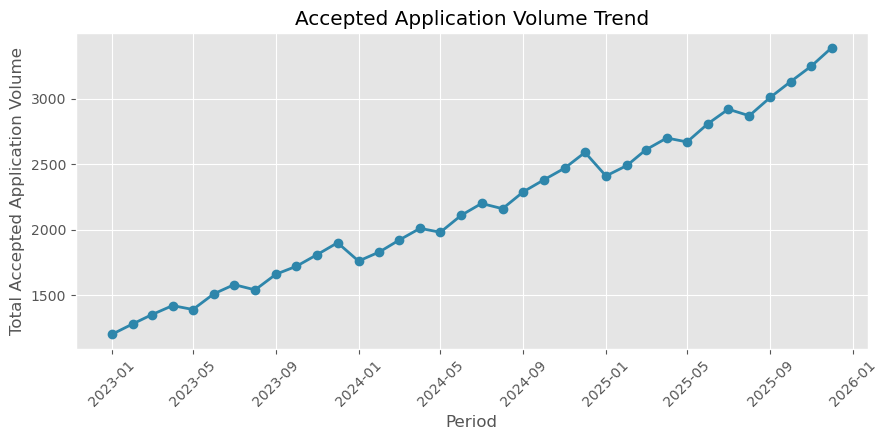

,period,total_accepted_application_volume,volume_change,volume_growth_pct
0,2023-01,1200,NaN,NaN
1,2023-02,1280,80.00,6.67
2,2023-03,1350,70.00,5.47
3,2023-04,1420,70.00,5.19
4,2023-05,1390,-30.00,-2.11
5,2023-06,1510,120.00,8.63
6,2023-07,1580,70.00,4.64
7,2023-08,1540,-40.00,-2.53
8,2023-09,1660,120.00,7.79
9,2023-10,1720,60.00,3.61


In [15]:
df["volume_change"] = df["total_accepted_application_volume"].diff()
df["volume_growth_pct"] = df["total_accepted_application_volume"].pct_change() * 100

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(df["date"], df["total_accepted_application_volume"], marker="o", linewidth=2, color="#2E86AB")
ax.set(title="Accepted Application Volume Trend", xlabel="Period", ylabel="Total Accepted Application Volume")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

df[["period", "total_accepted_application_volume", "volume_change", "volume_growth_pct"]]

In [16]:
total_volume_increase = df["total_accepted_application_volume"].iloc[-1] - df["total_accepted_application_volume"].iloc[0]
total_volume_increase_pct = total_volume_increase / df["total_accepted_application_volume"].iloc[0] * 100
average_monthly_volume_change = df["total_accepted_application_volume"].diff().mean()

print(f"Total volume increase: {total_volume_increase:,.0f} ({total_volume_increase_pct:.2f}%)")
print(f"Average monthly volume change: {average_monthly_volume_change:,.0f}")

Total volume increase: 2,190 (182.50%)
Average monthly volume change: 63


**Interpretasi:** Grafik dan tabel menunjukkan perubahan total volume pengajuan yang diterima pada setiap periode. Variabel ini merupakan salah satu input utama karena peningkatan volume pengajuan yang diterima berpotensi meningkatkan kebutuhan dana.

## 3. Tren harga acuan

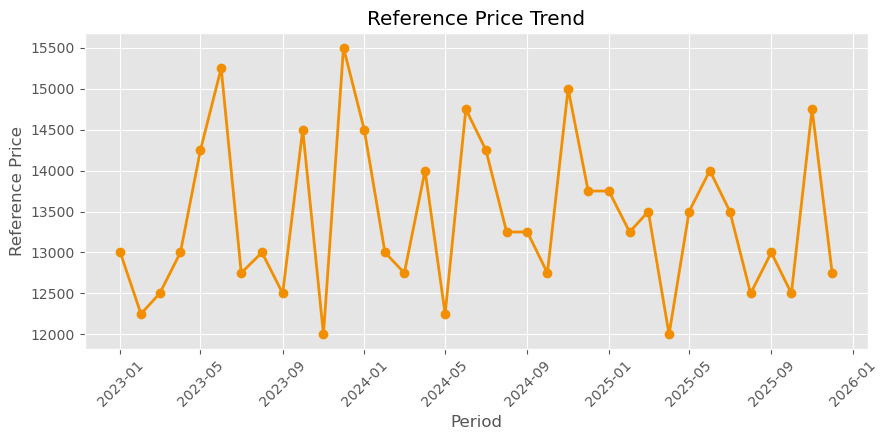

,period,reference_price,price_change,price_growth_pct
0,2023-01,13000,NaN,NaN
1,2023-02,12250,-750.00,-5.77
2,2023-03,12500,250.00,2.04
3,2023-04,13000,500.00,4.00
4,2023-05,14250,"1,250.00",9.62
5,2023-06,15250,"1,000.00",7.02
6,2023-07,12750,"-2,500.00",-16.39
7,2023-08,13000,250.00,1.96
8,2023-09,12500,-500.00,-3.85
9,2023-10,14500,"2,000.00",16.00


In [17]:
df["price_change"] = df["reference_price"].diff()
df["price_growth_pct"] = df["reference_price"].pct_change() * 100

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(df["date"], df["reference_price"], marker="o", linewidth=2, color="#F18F01")
ax.set(title="Reference Price Trend", xlabel="Period", ylabel="Reference Price")
ax.ticklabel_format(style="plain", axis="y")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

df[["period", "reference_price", "price_change", "price_growth_pct"]]

In [18]:
total_price_increase = df["reference_price"].iloc[-1] - df["reference_price"].iloc[0]
total_price_increase_pct = total_price_increase / df["reference_price"].iloc[0] * 100

print(f"Total price increase: IDR {total_price_increase:,.0f} ({total_price_increase_pct:.2f}%)")
print(f"Average reference price: IDR {df['reference_price'].mean():,.0f}")

Total price increase: IDR -250 (-1.92%)
Average reference price: IDR 13,417


**Interpretasi:** Harga acuan dapat berubah pada setiap periode sesuai keputusan stakeholder. Oleh karena itu, nilainya tidak diasumsikan mengikuti pola waktu tertentu. Grafik digunakan untuk menunjukkan variasi keputusan harga, bukan untuk meramalkan harga acuan berikutnya.

## 4. Estimasi kebutuhan dana

Estimasi dana setiap periode dihitung dari total volume pengajuan diterima dikali harga acuan yang ditentukan stakeholder.

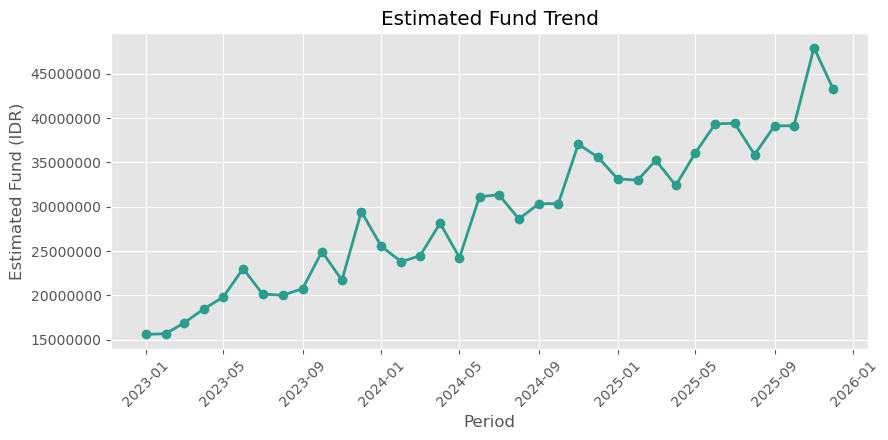

,period,total_accepted_application_volume,reference_price,estimated_fund
0,2023-01,1200,13000,15600000
1,2023-02,1280,12250,15680000
2,2023-03,1350,12500,16875000
3,2023-04,1420,13000,18460000
4,2023-05,1390,14250,19807500
5,2023-06,1510,15250,23027500
6,2023-07,1580,12750,20145000
7,2023-08,1540,13000,20020000
8,2023-09,1660,12500,20750000
9,2023-10,1720,14500,24940000


In [19]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(df["date"], df["estimated_fund"], marker="o", linewidth=2, color="#2A9D8F")
ax.set(title="Estimated Fund Trend", xlabel="Period", ylabel="Estimated Fund (IDR)")
ax.tick_params(axis="x", rotation=45)
ax.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()

df[[
    "period",
    "total_accepted_application_volume",
    "reference_price",
    "estimated_fund",
]].head(12)

**Interpretasi:** Nilai estimasi dana berubah mengikuti kombinasi volume historis dan harga acuan stakeholder. Pada volume yang sama, harga acuan yang lebih tinggi menghasilkan kebutuhan dana yang lebih besar. Sebaliknya, perubahan harga tidak mengubah data volume historis.

## 5. Korelasi

Korelasi dihitung untuk memahami hubungan historis antarvariabel. `time_index` digunakan untuk memeriksa tren volume, sedangkan harga acuan diperlakukan sebagai input stakeholder. `estimated_fund` ikut dianalisis, tetapi hubungannya dengan volume dan harga sudah terbentuk secara matematis melalui operasi perkalian.

,time_index,total_accepted_application_volume,reference_price,estimated_fund
time_index,1.00,0.99,-0.00,0.96
total_accepted_application_volume,0.99,1.00,0.01,0.97
reference_price,-0.00,0.01,1.00,0.25
estimated_fund,0.96,0.97,0.25,1.00


Correlation between time and volume: 0.9916
Correlation between time and price: -0.0000
Correlation between accepted volume and reference price: 0.0085
Correlation between estimated fund and accepted volume: 0.9695
Correlation between estimated fund and reference price: 0.2450


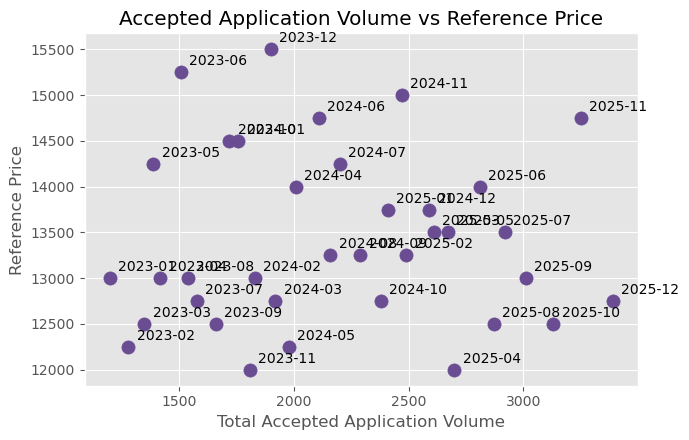

In [20]:
correlation_columns = [
    "time_index",
    "total_accepted_application_volume",
    "reference_price",
    "estimated_fund",
]
correlation_matrix = df[correlation_columns].corr(method="pearson")
volume_price_correlation = correlation_matrix.loc[
    "total_accepted_application_volume", "reference_price"
]
volume_time_correlation = correlation_matrix.loc[
    "time_index", "total_accepted_application_volume"
]
price_time_correlation = correlation_matrix.loc["time_index", "reference_price"]
fund_volume_correlation = correlation_matrix.loc[
    "estimated_fund", "total_accepted_application_volume"
]
fund_price_correlation = correlation_matrix.loc[
    "estimated_fund", "reference_price"
]

display(correlation_matrix)
print(f"Correlation between time and volume: {volume_time_correlation:.4f}")
print(f"Correlation between time and price: {price_time_correlation:.4f}")
print(f"Correlation between accepted volume and reference price: {volume_price_correlation:.4f}")
print(f"Correlation between estimated fund and accepted volume: {fund_volume_correlation:.4f}")
print(f"Correlation between estimated fund and reference price: {fund_price_correlation:.4f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(
    df["total_accepted_application_volume"],
    df["reference_price"],
    s=90,
    color="#6A4C93",
)
for _, row in df.iterrows():
    ax.annotate(
        row["period"],
        (row["total_accepted_application_volume"], row["reference_price"]),
        xytext=(6, 5),
        textcoords="offset points",
    )
ax.set(
    title="Accepted Application Volume vs Reference Price",
    xlabel="Total Accepted Application Volume",
    ylabel="Reference Price",
)
ax.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()

**Interpretasi:** Korelasi waktu–volume membantu melihat tren historis volume pengajuan. Harga acuan tidak diprediksi karena nilainya ditentukan stakeholder. Korelasi `estimated_fund` terhadap volume dan harga hanya menjelaskan dampak kedua komponen dalam rumus perkalian, bukan hubungan sebab-akibat yang ditemukan oleh model.

## 6. Missing value

In [21]:
source_columns = [
    "period",
    "total_accepted_application_volume",
    "reference_price",
]
missing_summary = pd.DataFrame({
    "missing_count": df[source_columns].isna().sum(),
    "missing_percentage": df[source_columns].isna().mean() * 100,
})
missing_summary

,missing_count,missing_percentage
period,0,0.00
total_accepted_application_volume,0,0.00
reference_price,0,0.00


**Interpretasi:** Dataset sumber tidak memiliki missing value pada kolom `period`, `total_accepted_application_volume`, maupun `reference_price`, sehingga seluruh observasi dapat digunakan untuk EDA.

## 7. Kesimpulan

- Kolom `period` telah dikonversi dari teks menjadi `datetime`, lalu direpresentasikan secara numerik menggunakan `year`, `month_number`, dan `time_index`.
- Dataset mencakup 36 observasi bulanan dari Januari 2023 sampai Desember 2025.
- Total volume pengajuan diterima memiliki tren historis, sedangkan harga acuan merupakan input skenario yang dapat ditentukan stakeholder kapan saja.
- Harga acuan tidak perlu diprediksi dari periode dan tidak diasumsikan memiliki tren waktu.
- Korelasi Pearson hanya digunakan sebagai pemeriksaan diagnostik dan tidak membuktikan sebab-akibat.
- Data sumber lengkap dan tidak memiliki missing value.
- Harga acuan merupakan input yang dapat ditentukan stakeholder untuk setiap skenario.
- Estimasi dana dihitung menggunakan `total_accepted_application_volume × reference_price`.
- Jika volume periode berikutnya belum diketahui, machine learning dapat digunakan hanya untuk memprediksi volume berdasarkan histori. Hasil prediksi volume kemudian dikalikan dengan harga acuan stakeholder.
- Jika volume sudah diketahui, estimasi dana cukup menggunakan rumus perkalian tanpa proses prediksi.